# Calculation general CME distributions in $\beta$

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

import dependencies

In [9]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad


Define the 3D distribution as a function of lattitude $\alpha$.
(obtained in experimental_flare_distribution.ipynb)

In [26]:
# general distribution of active regions per unit area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)
Rn = 1
def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err) / Rn
            # fit of dist when integrated over phi and absolute value so accounting for that

Rn = quad(lambda x : rho(x) * np.sin(x) , 0, np.pi)[0]

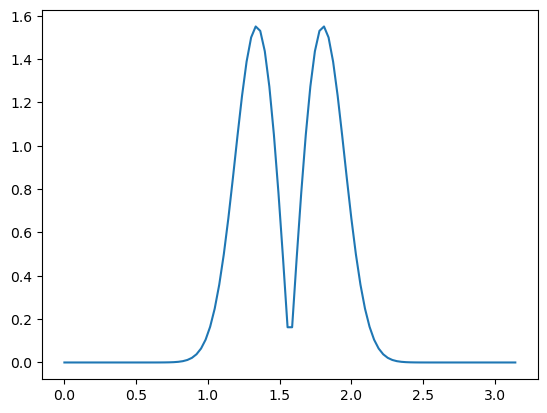

In [27]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))

Before for flare distribution we had the relation
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$

Now we work with different variables but they are similar as follows $\beta \sim \alpha, \theta \sim \tau, \theta'\sim \theta$ and $ \phi'\sim \phi$ so  
$$
\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta  $$
For a proper description we refer to the associated paper.



The distribution for CME angle is assumed to be gaussion around 0 in the angle with the zenit. We here under properly normalize the distribution!

0.4946944833802725
1.0


Text(0, 0.5, "distribution of CMEs at angle $\\theta'$ with the zenit")

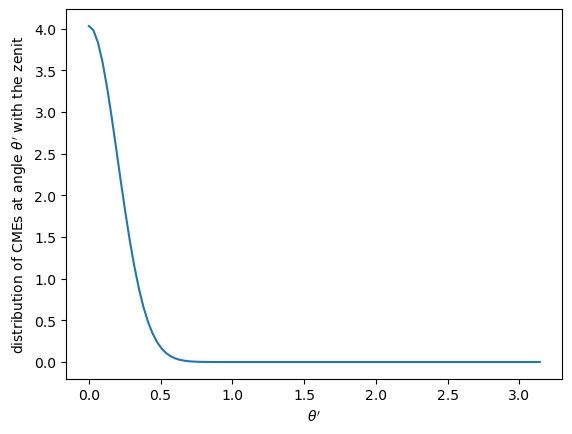

In [13]:
from scipy.stats import norm
# normalization, later to be determined
N = 1

def rho_CME(theta2, loc=0, scale = 0.2):
    return norm.pdf(theta2, loc, scale) /N

f = lambda theta2 : rho_CME(theta2) * np.sin(theta2) * 2 * np.pi


N = quad(f, 0, np.pi/2)[0]
print(N)
print(quad(f, 0, np.pi/2)[0])

T = np.linspace(0, np.pi, 100)
plt.plot(T, rho_CME(T))
plt.xlabel("$\\theta'$")
plt.ylabel("distribution of CMEs at angle $\\theta'$ with the zenit")



# Calculation of distribution of CMEs in viewing angle $\beta$ for given $\tau$.

Now we calculate the distribution in viewing angle $\beta$ for a given orientation angle $\tau$. 
This is a numerically exhausting procedure. 
We have a fast (monte carlo) and a slow approach (scipy.integrate.nquad) however it in both options struggles to get sufficient datapoints with good accuracy.

Later we will calculate the distribution of CMEs in viewing angle $\beta$ for average $\tau$ which can be analytically simplified and quickly solved.

In [ ]:
# general distribution for given tau
def get_sinphi2(theta, phi, theta2, beta):
    cosphi2 = (np.cos(beta)  - np.cos(theta)*np.cos(theta2) )/ (np.sin(theta)*np.sin(theta2)) 
    return 0 if np.abs(cosphi2) >1 else (1-cosphi2**2)**0.5

def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))



def f_integrand_(beta, tau, vec=True):
    if vec:
        def integrand_vec(x):
            theta = x[0]
            phi = x[1]
            theta2 = x[2]
            return integrand(theta, phi, theta2, beta, tau)
        return integrand_vec
    else:
        def integrand2(theta, phi, theta2):
            return integrand(theta, phi, theta2, beta, tau)
        return integrand2

# def integrand(theta, phi, theta2, beta, tau):
#     sinphi2 = get_sinphi2(theta, phi, theta2, beta)
#     alpha = get_alpha(tau, theta, phi)
        
#     return np.sin(theta)**2 * rho(alpha) * np.sin(theta2)**2 * rho_CME(theta2) * sinphi2 


def integrand(theta, phi, theta2, beta, tau):
    sinphi2 = get_sinphi2(theta, phi, theta2, beta)
    alpha = get_alpha(tau, theta, phi)
        
    return np.sin(theta) * rho(alpha) * np.sin(theta2) * rho_CME(theta2) *   ((np.sin(theta)  * np.sin(theta2))**2 - (np.cos(beta) - np.cos(theta) * np.cos(theta2))**2 +0.001)**0.5 

If all integrations can be done at once this will save much time!
\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] \times [0,2\pi ]}d\theta d\phi d\theta' d\phi' \sin\theta   
    \rho (\alpha(\theta, \phi)) \sin\theta'  \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

so we use $\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta$, or equivalently that
$\cos \phi' = \frac{\cos\beta - \cos\theta'\cos\theta}{\sin \theta'\sin\theta}$
to find that 


\begin{equation}
    \int d\phi'   \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta)) = \frac{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}
since $\int dx \delta(f(x)) = \int dy (f'(x))^{-1} \delta(y) = 1/f'(x_0)$ where $y=f(x)$ and  $x_0$ such that $y=f(x_0)=0$.

Therefore 
\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'  \sin\theta   
    \rho (\alpha(\theta, \phi)) \sin\theta'  \rho^{CME}(\theta')  \frac{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'   
    \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta')  \frac{\sin^2\theta\sin^2\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'   
    \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta')  \frac{\sin\theta\sin\theta'\sqrt{\sin^2 \theta \sin^2 \theta' - (\cos \beta - \cos \theta \cos \theta')^2 }}{|\sin\beta|}
\end{equation}


This calculation will take a while.



# intergral numerical

In [42]:
import time
# import mcint
import random
import math
from scipy.integrate import nquad

# epsabs=1e-10, epsrel=1e-10,

def sampler():
    while True:
        theta     = random.uniform(0, np.pi)
        phi  = random.uniform(0, 2*np.pi)
        theta2    = random.uniform(0, np.pi/2)
    
        yield (theta, phi, theta2)

def get_rho_beta(beta, tau):
    start_time = time.time()
    print(beta, tau, end='\r')
    result, error = nquad(f_integrand_(beta, tau, vec=False), [[0, np.pi],       # theta, phi, theta2
                                                [0, 2*np.pi],         # phi
                                                [0, np.pi / 2 ]], opts={"epsrel":0.05, 'epsabs':1e-1})       # theta2
    end_time = time.time()
    print(f'For params {beta=}, {tau = } we find the distibution to be {result/ (np.abs(np.sin(beta)) +0.001)}, with estimated error {error/ (np.abs(np.sin(beta)) +0.001)}. \
        Taking {(end_time-start_time):.2f} to calculate.')

    return result/ (np.abs(np.sin(beta)) +0.001)


def rho_betas(betas, tau):
    return [get_rho_beta(beta, tau) for beta in betas]

betas = np.linspace(0,np.pi/2, 20)
Taus =  np.linspace(0,np.pi/2, 5)

x = np.linspace(0,np.pi, 300)

# for tau :
#     a = rho_betas(betas, tau, fast)
#     plt.plot(betas, a, label=fr'$\tau=${round(tau*180/np.pi)}°')
#     print(betas, a)

def run_taus(T):
    dens = []
    for tau in T:
        print(f"calculating tau = {tau}")
        dens.append(rho_betas(betas, tau))

    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs")
    plt.xticks(np.linspace(0,np.pi, 4), range(0,181,60))
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi)
    plt.show()
    return dens



dens = run_taus(Taus)


calculating tau = 0.0


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_11628\3892644507.py:35: RuntimeWarning: invalid value encountered in scalar power
  return np.sin(theta) * rho(alpha) * np.sin(theta2) * rho_CME(theta2) *   ((np.sin(theta)  * np.sin(theta2))**2 - (np.cos(beta) - np.cos(theta) * np.cos(theta2))**2 +0.001)**0.5
c:\Users\mdewilde\AppData\Local\anaconda3\Lib\site-packages\scipy\integrate\_quadpack_py.py:1260: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


KeyboardInterrupt: 

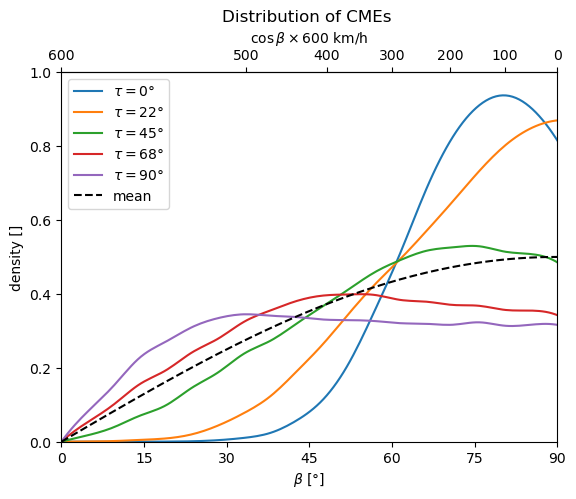

In [23]:

# renomalize
K = np.average(dens[0]) * np.pi 

def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/K)(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)



numerical (not yet enough accruracy)
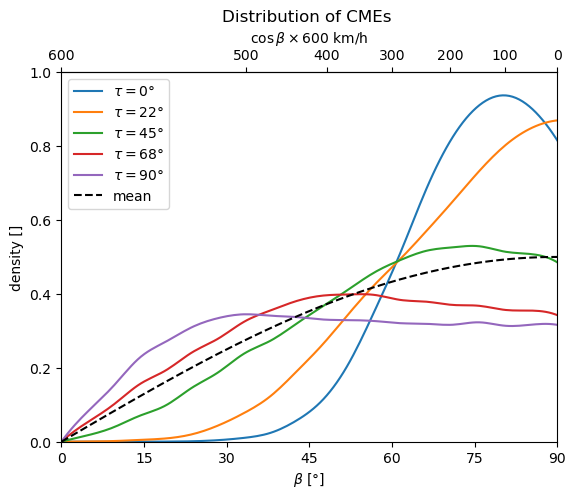
Monte carlo (with sin at 0)
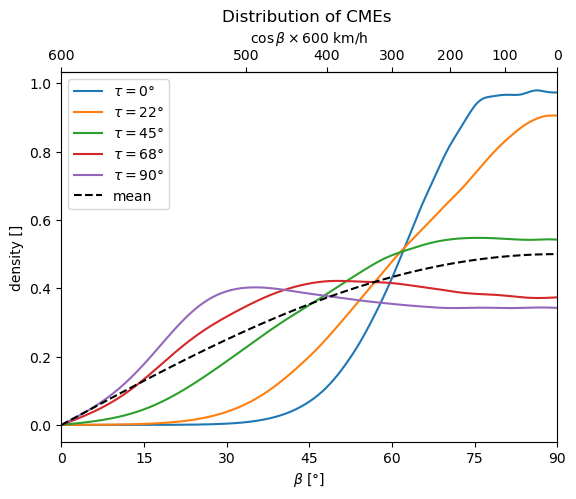


In [9]:
def CME_dist():
    T = np.linspace(0, np.pi/2, 5)
    dens = run_taus(T)
    plotting_(dens, T)

# Polar flares

0.5000000000000001


Text(0, 0.5, 'probability density per unit area')

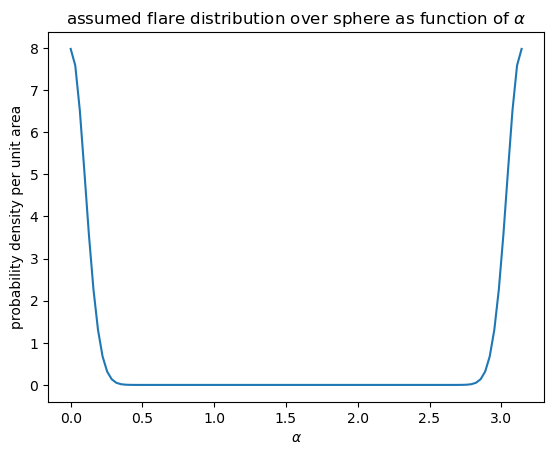

In [ ]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return (norm.pdf(alpha, loc, scale) + norm.pdf(alpha, loc+np.pi, scale)) /N

N = quad(lambda a :  rho(a), 0, np.pi/2)[0]
print(N)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [ ]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

    
def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()


0.0 (0.9993158136231646, 3.647190528409362e-12)
0.39269908169872414 (0.9993158136231631, 1.694194277505706e-13)
0.7853981633974483 (0.9993158136231668, 7.908570194260995e-11)
1.1780972450961724 (0.9993158136231668, 4.542747928977166e-09)
1.5707963267948966 (0.9993158136231646, 1.2719183056504428e-09)


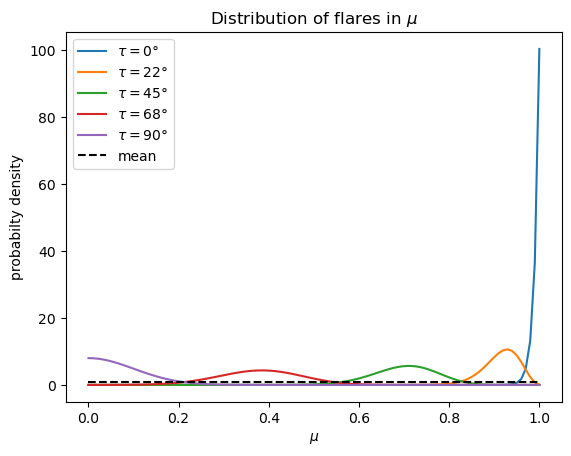

calculating tau = 0.0
calculating tau = 0.39269908169872414
calculating tau = 0.7853981633974483
calculating tau = 1.1780972450961724
calculating tau = 1.5707963267948966


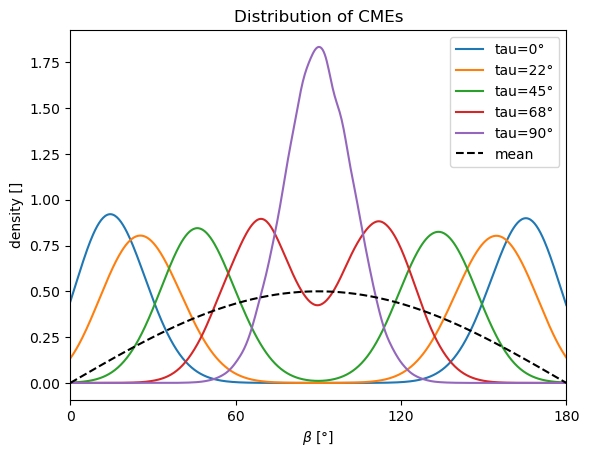

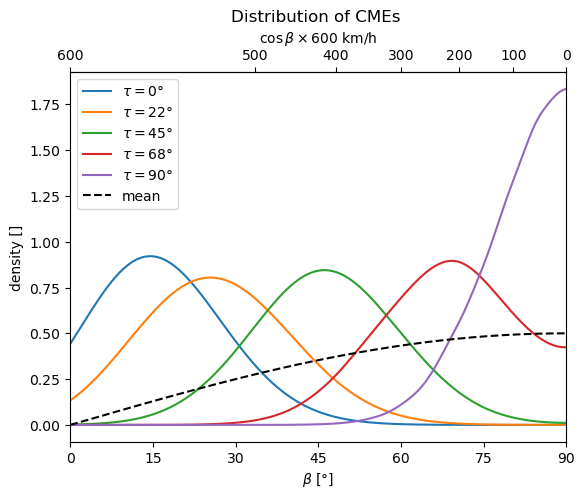

In [ ]:
Flare_dist()
CME_dist()

# flares around Equator (normal dist, no dip)

Text(0, 0.5, 'probability density per unit area')

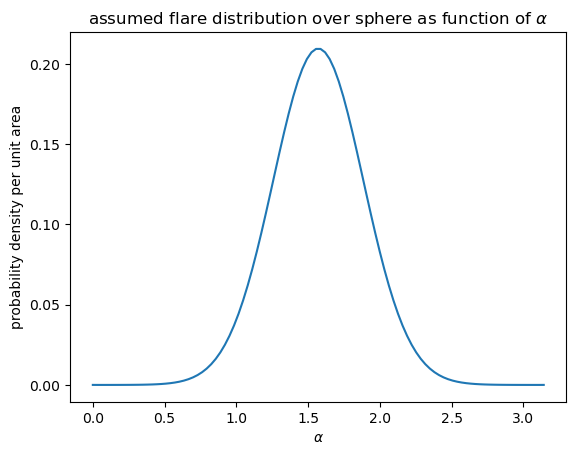

In [ ]:
from scipy.stats import norm

def rho(alpha, loc=np.pi/2, scale = 0.3, err = 0.01):
    return norm.pdf(alpha, loc, scale) / 2 / np.pi / (np.sin(alpha) + err) 

alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

calculating tau = 0.0
calculating tau = 0.39269908169872414
calculating tau = 0.7853981633974483
calculating tau = 1.1780972450961724
calculating tau = 1.5707963267948966


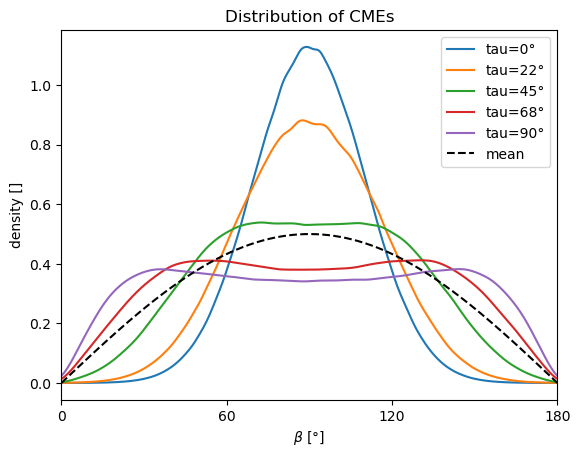

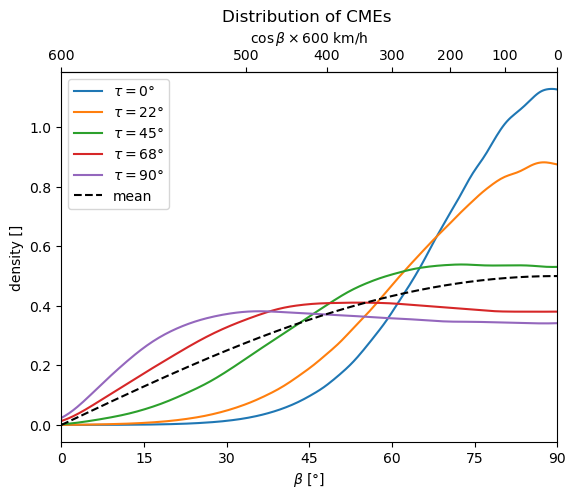

In [ ]:
CME_dist()

# Flares with stepfunction dist around equator

Text(0, 0.5, 'probability density per unit area')

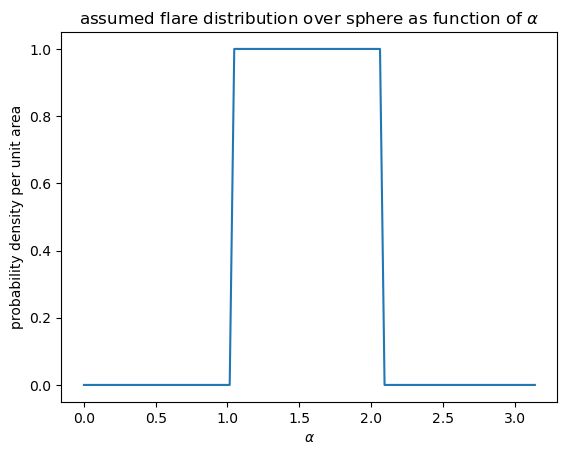

In [ ]:
def rho(alpha, h=30/180*np.pi):
    return np.where(np.abs(alpha-np.pi/2) < h, 1, 0)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

calculating tau = 0.0
calculating tau = 0.39269908169872414
calculating tau = 0.7853981633974483
calculating tau = 1.1780972450961724
calculating tau = 1.5707963267948966


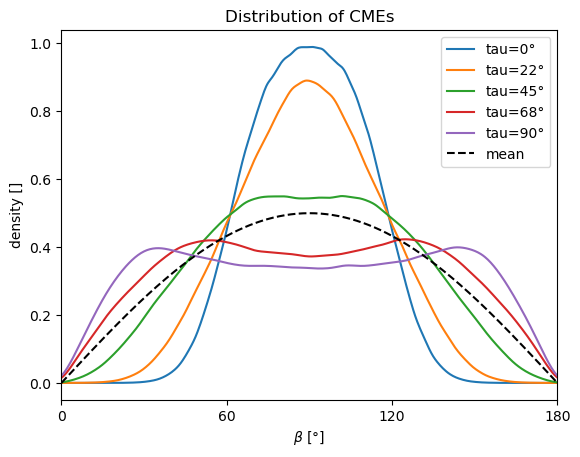

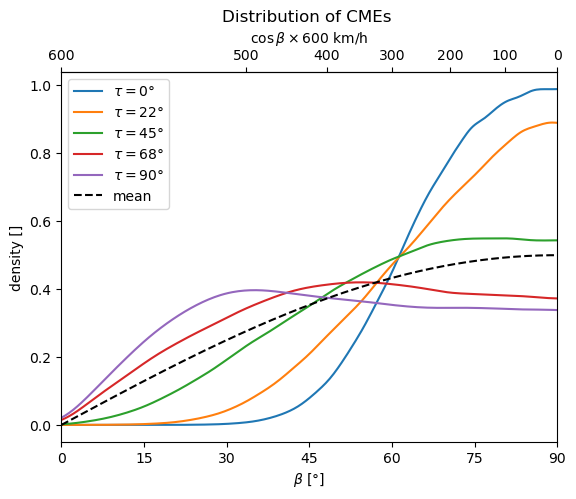

In [ ]:
CME_dist()